# Проект: нейросеть для автодополнения текстов

Сравнение word-level моделей LSTM и GRU с предобученным `distilgpt2` на WikiText-2. Для LSTM/GRU используется собственная пословная токенизация, а `distilgpt2` — свой BPE-токенизатор, поэтому perplexity трансформера является дополнительным ориентиром, а не полностью прямым сравнением.

In [16]:
!pip install datasets numpy pandas matplotlib transformers

Looking in indexes: https://nexus-docker-proxy.biotech.biotc.ru/repository/pypi-all/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 132.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.0/805.0 kB 84.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 113.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.3/123.3 kB 29.9 MB/s eta 0:00:00
  Using cached https://nexus-docker-proxy.biotech.biotc.ru/repository/pypi-all/packages/safetensors/0.8.0/safetensors-0.8.0-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (516 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 112.4 MB/s eta 0:00:00
  Using cached https://nexus-docker-proxy.biotech.biotc.ru/repository/pypi-all/packages/httpx/0.28.1/httpx-0.28.1-py3-none-any.whl (73 kB)
  Using cached https://nexus-docker-proxy.biotech.biotc.ru/repository/pypi-all/packages/shellingham/1.5.4/shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
  Using cac

In [7]:
!pip install --force-reinstall torch==2.9.1 --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached filelock-3.32.3-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 91.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 142.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 94.6 MB/s eta 0:00:00ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 33.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 39.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 54.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [10]:
import math
import random
import re
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# False — итоговый запуск на всей выборке. True — быстрая проверка кода.
FAST_MODE = False
SEQ_LEN, MIN_FREQ = 32, 2
EMBED_DIM, HIDDEN_DIM, NUM_LAYERS = 128, 256, 2
BATCH_SIZE, EPOCHS, LEARNING_RATE, GRAD_CLIP = 64, 3, 1e-3, 1.0
if FAST_MODE:
    EPOCHS, BATCH_SIZE = 1, 32
    MAX_TRAIN_BATCHES, MAX_EVAL_BATCHES, MAX_TRANSFORMER_EXAMPLES = 30, 10, 64
else:
    MAX_TRAIN_BATCHES = MAX_EVAL_BATCHES = MAX_TRANSFORMER_EXAMPLES = None
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if device.type == 'cuda':
#     capability = torch.cuda.get_device_capability()
#     print(f'GPU compute capability: {capability[0]}.{capability[1]}')
#     # if capability < (7, 5):
#     #     # cuDNN 9.x не поддерживает старые GPU с SM ниже 7.5.
#     #     # LSTM/GRU продолжат работать через совместимый PyTorch-бэкенд.
#     #     torch.backends.cudnn.enabled = False
#     #     print('cuDNN отключён для совместимости со старой видеокартой.')
    
#     device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'device: {device}, torch: {torch.__version__}')

device: cuda, torch: 2.9.1+cu126


## 1. Загрузка WikiText-2 и разведочный анализ

Пустые строки исключаются из статистик и подготовки данных.

/home/froschin/work/masters_degree_Roshchin_M25-555/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,split,non_empty_texts,tokens,mean_tokens,median_tokens,max_tokens
0,train,23767,2122137,89.29,77.0,733
1,validation,2461,221611,90.05,78.0,434
2,test,2891,249691,86.37,69.0,497


Примеры train:
1. = Valkyria Chronicles III =
2. Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in Janua
3. The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving for series newcomers . Character designer Raita Honj


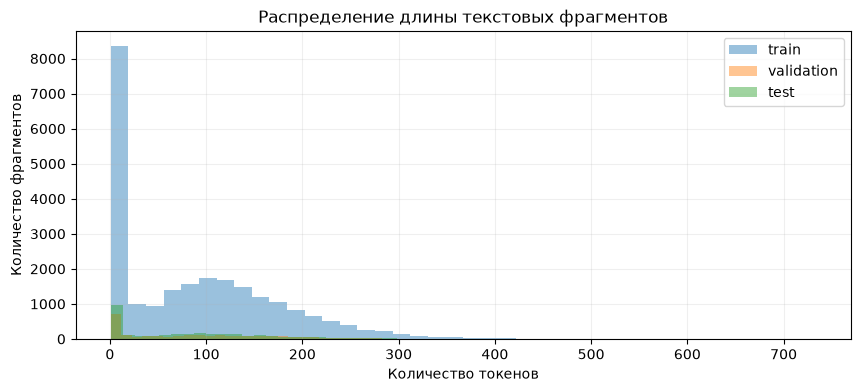

In [2]:
from datasets import load_dataset

dataset = load_dataset('Salesforce/wikitext', 'wikitext-2-raw-v1')
raw_splits = {s: [row['text'].strip() for row in dataset[s] if row['text'].strip()] for s in ('train','validation','test')}
TOKEN_PATTERN = re.compile(r'\w+|[^\w\s]', re.UNICODE)

def tokenize_words(text):
    return TOKEN_PATTERN.findall(text.lower())

stats = []
for split, texts in raw_splits.items():
    lengths = np.array([len(tokenize_words(t)) for t in texts])
    stats.append({'split':split, 'non_empty_texts':len(texts), 'tokens':int(lengths.sum()), 'mean_tokens':round(float(lengths.mean()),2), 'median_tokens':round(float(np.median(lengths)),2), 'max_tokens':int(lengths.max())})

display(pd.DataFrame(stats))
print('Примеры train:')

for i, text in enumerate(raw_splits['train'][:3], 1):
    print(f'{i}. {text[:300]}')

plt.figure(figsize=(10,4))
for split, texts in raw_splits.items(): plt.hist([len(tokenize_words(t)) for t in texts], bins=40, alpha=.45, label=split)
plt.title('Распределение длины текстовых фрагментов')
plt.xlabel('Количество токенов')
plt.ylabel('Количество фрагментов')
plt.legend()
plt.grid(alpha=.2)
plt.show()

In [3]:
def count_sentences(text):
    # Простая эвристика для EDA: предложения разделяются ., ! или ?
    return max(1, len([part for part in re.split(r'(?<=[.!?])\s+', text.strip()) if part]))

sentence_stats = pd.DataFrame([
    {'split': split, 'sentences': sum(count_sentences(t) for t in texts), 'mean_tokens_per_sentence': round(sum(len(tokenize_words(t)) for t in texts) / max(sum(count_sentences(t) for t in texts), 1), 2)}
    for split, texts in raw_splits.items()
])
display(sentence_stats)

,split,sentences,mean_tokens_per_sentence
0,train,88275,24.04
1,validation,9335,23.74
2,test,10561,23.64


## 2. Пословная токенизация и Dataset

Словарь строится только по train. Редкие слова заменяются на `<unk>`, конец строки отмечается `<eos>`. Вход и таргет сдвинуты на один токен.

In [4]:
SPECIAL_TOKENS = ['<pad>', '<unk>', '<eos>']
counter = Counter(tok for text in raw_splits['train'] for tok in tokenize_words(text))
itos = SPECIAL_TOKENS + sorted(tok for tok, freq in counter.items() if freq >= MIN_FREQ)
stoi = {tok:i for i,tok in enumerate(itos)}
PAD_ID, UNK_ID, EOS_ID = [stoi[t] for t in SPECIAL_TOKENS]

def encode_split(texts):
    ids = []
    for text in texts:
        ids.extend(stoi.get(tok, UNK_ID) for tok in tokenize_words(text))
        ids.append(EOS_ID)
    return torch.tensor(ids, dtype=torch.long)
encoded_splits = {s: encode_split(texts) for s,texts in raw_splits.items()}

class LanguageModelDataset(Dataset):
    def __init__(self, token_ids, seq_len, stride=None):
        self.token_ids, self.seq_len, self.stride = token_ids, seq_len, stride or seq_len
        max_start = len(token_ids) - seq_len - 1
        self.starts = list(range(0, max_start + 1, self.stride))
    def __len__(self):
        return len(self.starts)
    def __getitem__(self, index):
        start = self.starts[index]
        window = self.token_ids[start:start+self.seq_len+1]
        return window[:-1], window[1:]

lm_datasets = {s: LanguageModelDataset(ids, SEQ_LEN) for s,ids in encoded_splits.items()}
loaders = {s: DataLoader(lm_datasets[s], batch_size=BATCH_SIZE, shuffle=(s=='train'), num_workers=0, pin_memory=device.type=='cuda') for s in ('train','validation','test')}
print(f'Размер словаря: {len(itos):,}')
print('Токенов:', {s:len(x) for s,x in encoded_splits.items()})
print('Примеров:', {s:len(x) for s,x in lm_datasets.items()})
x_sample, y_sample = next(iter(loaders['train']))
print('X/Y:', tuple(x_sample.shape), tuple(y_sample.shape))
assert torch.equal(x_sample[:,1:], y_sample[:,:-1])

Размер словаря: 39,149
Токенов: {'train': 2145904, 'validation': 224072, 'test': 252582}
Примеров: {'train': 67059, 'validation': 7002, 'test': 7893}
X/Y: (64, 32) (64, 32)


## 3. LSTM/GRU: модель, обучение и метрики

Используются `Embedding + RNN + Linear`, `CrossEntropyLoss` и gradient clipping. Perplexity равна `exp(loss)`. 

In [11]:
class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2, rnn_type='LSTM', dropout=.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_ID)
        rnn_cls = nn.LSTM if rnn_type.upper() == 'LSTM' else nn.GRU
        self.rnn = rnn_cls(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers>1 else 0.)
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_dim, vocab_size)
    def forward(self, input_ids):
        h, _ = self.rnn(self.dropout(self.embedding(input_ids)))
        return self.output(self.dropout(h))

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def perplexity(loss):
    return float(math.exp(min(float(loss), 20)))

criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer=None, max_batches=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0
    total_tokens = 0
    for batch_index, (inputs, targets) in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches: break
        inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        if training: optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            logits = model(inputs)
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
        n = targets.numel()
        total_loss += loss.item()*n
        total_tokens += n
    return total_loss / max(total_tokens, 1)

def fit_model(model, name):
    # global device
    # if torch.cuda.is_available() and torch.cuda.get_device_capability() < (7, 5):
    #     device = torch.device('cpu')
    #     print('GPU несовместима с текущим PyTorch. Обучение переключено на CPU.')
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = []
    for epoch in range(1, EPOCHS+1):
        started = time.perf_counter()
        train_loss = run_epoch(model, loaders['train'], optimizer, MAX_TRAIN_BATCHES)
        val_loss = run_epoch(model, loaders['validation'], max_batches=MAX_EVAL_BATCHES)
        elapsed = time.perf_counter()-started
        row = {'epoch':epoch, 'train_loss':train_loss, 'val_loss':val_loss, 'train_ppl':perplexity(train_loss), 'val_ppl':perplexity(val_loss), 'epoch_time_sec':elapsed}
        history.append(row)
        print(f"{name} | epoch {epoch:02d}/{EPOCHS} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | val perplexity {row['val_ppl']:.2f} | {elapsed:.1f} sec")
    return pd.DataFrame(history)
def evaluate_rnn(model, split):
    loss = run_epoch(model, loaders[split], max_batches=MAX_EVAL_BATCHES)
    return loss, perplexity(loss)

### Обучение LSTM

In [12]:
lstm_model = RNNLanguageModel(len(itos), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, 'LSTM')
print(f'Параметров LSTM: {count_parameters(lstm_model):,}')
lstm_history = fit_model(lstm_model, 'LSTM')
lstm_test_loss, lstm_test_ppl = evaluate_rnn(lstm_model, 'test')
print(f'LSTM test loss: {lstm_test_loss:.4f}, test perplexity: {lstm_test_ppl:.2f}')

Параметров LSTM: 15,993,965
LSTM | epoch 01/3 | train loss 6.9146 | val loss 6.1667 | val perplexity 476.62 | 27.9 sec
LSTM | epoch 02/3 | train loss 6.1807 | val loss 5.7726 | val perplexity 321.37 | 27.7 sec
LSTM | epoch 03/3 | train loss 5.8443 | val loss 5.5832 | val perplexity 265.91 | 27.9 sec
LSTM test loss: 5.5562, test perplexity: 258.82


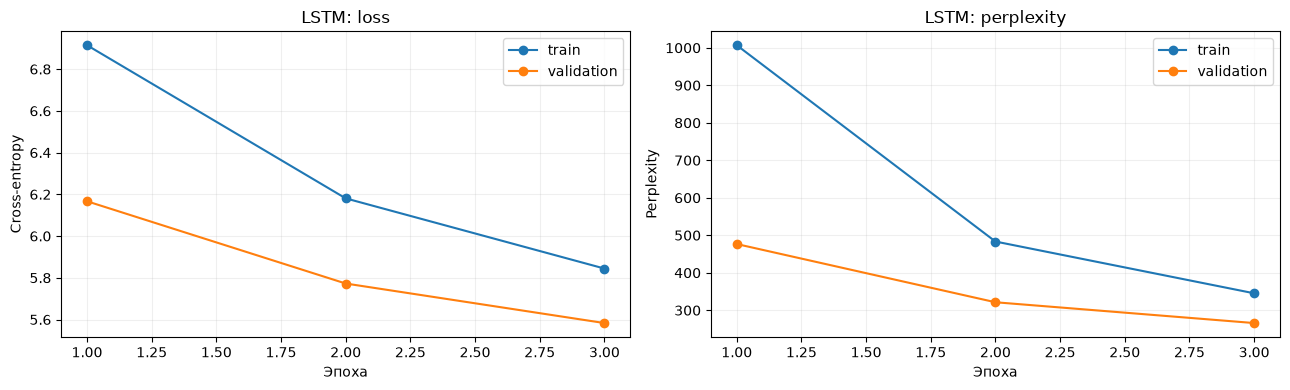

In [13]:
def plot_history(history, title):
    fig, axes = plt.subplots(1,2,figsize=(13,4))
    axes[0].plot(history.epoch, history.train_loss, marker='o', label='train')
    axes[0].plot(history.epoch, history.val_loss, marker='o', label='validation')
    axes[0].set_title(f'{title}: loss')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Cross-entropy')
    axes[0].legend()
    axes[0].grid(alpha=.2)
    axes[1].plot(history.epoch, history.train_ppl, marker='o', label='train')
    axes[1].plot(history.epoch, history.val_ppl, marker='o', label='validation')
    axes[1].set_title(f'{title}: perplexity')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Perplexity')
    axes[1].legend()
    axes[1].grid(alpha=.2)
    plt.tight_layout()
    plt.show()
plot_history(lstm_history, 'LSTM')

### Эксперимент GRU против LSTM

GRU обучается с теми же гиперпараметрами. Сравниваются perplexity, число параметров и среднее время эпохи.

Параметров GRU: 15,763,565
GRU | epoch 01/3 | train loss 6.8300 | val loss 6.1231 | val perplexity 456.28 | 27.4 sec
GRU | epoch 02/3 | train loss 6.1743 | val loss 5.7014 | val perplexity 299.30 | 27.5 sec
GRU | epoch 03/3 | train loss 5.7877 | val loss 5.4724 | val perplexity 238.03 | 27.6 sec
GRU test loss: 5.4306, test perplexity: 228.28


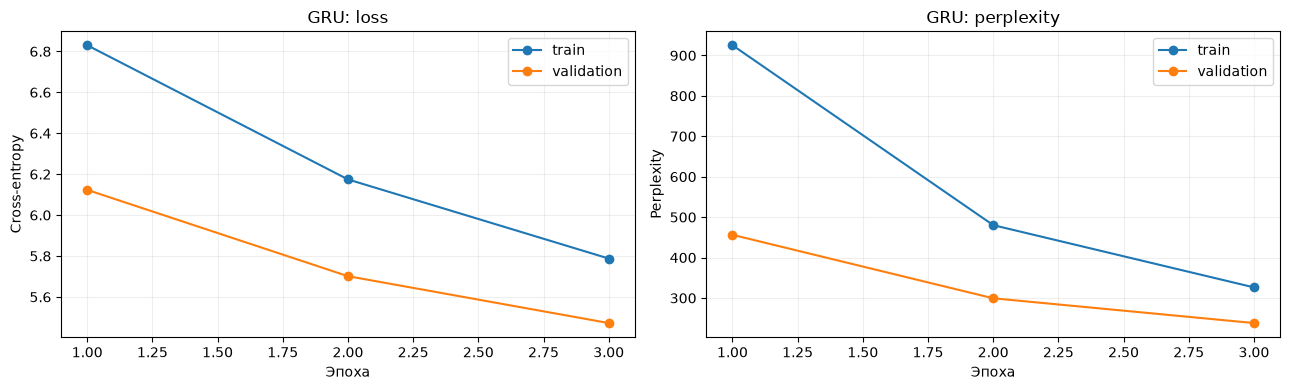

,model,parameters,val_perplexity,test_perplexity,mean_epoch_time_sec
0,LSTM,"15,993,965",265.91,258.82,27.85
1,GRU,"15,763,565",238.03,228.28,27.51


In [14]:
gru_model = RNNLanguageModel(len(itos), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, 'GRU')
print(f'Параметров GRU: {count_parameters(gru_model):,}')
gru_history = fit_model(gru_model, 'GRU')
gru_test_loss, gru_test_ppl = evaluate_rnn(gru_model, 'test')
print(f'GRU test loss: {gru_test_loss:.4f}, test perplexity: {gru_test_ppl:.2f}')
plot_history(gru_history, 'GRU')
rnn_experiment = pd.DataFrame([
 {'model':'LSTM','parameters':count_parameters(lstm_model),'val_perplexity':lstm_history.iloc[-1].val_ppl,'test_perplexity':lstm_test_ppl,'mean_epoch_time_sec':lstm_history.epoch_time_sec.mean()},
 {'model':'GRU','parameters':count_parameters(gru_model),'val_perplexity':gru_history.iloc[-1].val_ppl,'test_perplexity':gru_test_ppl,'mean_epoch_time_sec':gru_history.epoch_time_sec.mean()}])
display(rnn_experiment.style.format({'parameters':'{:,.0f}','val_perplexity':'{:.2f}','test_perplexity':'{:.2f}','mean_epoch_time_sec':'{:.2f}'}))

## 5. Оценка предобученного `distilgpt2`

Паддинг исключается из loss. Метрика считается отдельно на validation и test. Модель не дообучается на WikiText-2.

In [17]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
transformer_tokenizer = GPT2TokenizerFast.from_pretrained('distilgpt2')
transformer_model = GPT2LMHeadModel.from_pretrained('distilgpt2').to(device)
if transformer_tokenizer.pad_token is None:
    transformer_tokenizer.pad_token = transformer_tokenizer.eos_token
transformer_model.config.pad_token_id = transformer_tokenizer.pad_token_id
transformer_model.eval()
print(f'distilgpt2 parameters: {count_parameters(transformer_model):,}')

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 8930.05it/s]


distilgpt2 parameters: 81,912,576


In [18]:
def transformer_perplexity(model, tokenizer, texts, batch_size=8, max_length=256, max_examples=None):
    if model is None or tokenizer is None: return float('nan')
    texts = [t for t in texts if t.strip()]
    texts = texts if max_examples is None else texts[:max_examples]
    total_nll = total_tokens = 0
    model.eval()
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            encoded = tokenizer(texts[start:start+batch_size], return_tensors='pt', padding=True, truncation=True, max_length=max_length)
            ids, mask = encoded['input_ids'].to(device), encoded['attention_mask'].to(device)
            labels = ids.clone()
            labels[mask == 0] = -100
            valid = mask[:,1:].sum().item()
            if not valid:
                continue
            output = model(input_ids=ids, attention_mask=mask, labels=labels)
            total_nll += output.loss.item()*valid
            total_tokens += valid
    return perplexity(total_nll/total_tokens) if total_tokens else float('nan')

distil_val_ppl = transformer_perplexity(transformer_model, transformer_tokenizer, raw_splits['validation'], max_examples=MAX_TRANSFORMER_EXAMPLES)
distil_test_ppl = transformer_perplexity(transformer_model, transformer_tokenizer, raw_splits['test'], max_examples=MAX_TRANSFORMER_EXAMPLES)
print(f'distilgpt2 validation perplexity: {distil_val_ppl:.2f}')
print(f'distilgpt2 test perplexity: {distil_test_ppl:.2f}')

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


distilgpt2 validation perplexity: 73.98
distilgpt2 test perplexity: 72.71


## 6. Примеры автодополнения

Одинаковые контексты подаются всем моделям. Для LSTM/GRU выбирается наиболее вероятное следующее слово, а `distilgpt2` детерминированно генерирует продолжение.

In [19]:
def rnn_continuation(model, context, max_new_tokens=5):
    model.eval()
    context_tokens = tokenize_words(context)
    ids = [stoi.get(t, UNK_ID) for t in context_tokens]
    with torch.no_grad():
        for _ in range(max_new_tokens):
            inp = torch.tensor([ids[-SEQ_LEN:]], dtype=torch.long, device=device)
            next_id = int(torch.argmax(model(inp)[:,-1,:], dim=-1).item())
            ids.append(next_id)
    generated = [itos[i] for i in ids[len(context_tokens):] if i != EOS_ID]
    return context + ' ' + ' '.join(generated)

def transformer_continuation(context, max_new_tokens=5):
    if transformer_model is None: return 'Модель не загружена'
    encoded = transformer_tokenizer(context, return_tensors='pt').to(device)
    with torch.no_grad(): generated = transformer_model.generate(**encoded, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=transformer_tokenizer.pad_token_id)
    return transformer_tokenizer.decode(generated[0], skip_special_tokens=True)

contexts = ['the president of the','the weather today is','new york is a','the history of the','in the middle of the']
predictions = pd.DataFrame([{'context':c, 'LSTM':rnn_continuation(lstm_model,c), 'GRU':rnn_continuation(gru_model,c), 'distilgpt2':transformer_continuation(c)} for c in contexts])
display(predictions)

,context,LSTM,GRU,distilgpt2
0,the president of the,"the president of the <unk> , and the <unk>","the president of the <unk> , and the <unk>","the president of the United States, and the"
1,the weather today is,the weather today is a <unk> of the <unk>,the weather today is a <unk> of the <unk>,the weather today is a bit different than the
2,new york is a,"new york is a <unk> of the <unk> ,",new york is a <unk> of the <unk> <unk>,new york is a very good tool for building
3,the history of the,"the history of the <unk> , and the <unk>",the history of the game ' s first season,the history of the United States.”
4,in the middle of the,in the middle of the united states . =,"in the middle of the city , and the <unk>",in the middle of the night.\n\n\n


## 7. Сводная таблица и выводы

In [21]:
comparison_df = pd.DataFrame([
 {'model':'LSTM','parameters':count_parameters(lstm_model),'val_perplexity':float(lstm_history.iloc[-1].val_ppl),'test_perplexity':float(lstm_test_ppl),'time_per_epoch_sec':float(lstm_history.epoch_time_sec.mean())},
 {'model':'GRU','parameters':count_parameters(gru_model),'val_perplexity':float(gru_history.iloc[-1].val_ppl),'test_perplexity':float(gru_test_ppl),'time_per_epoch_sec':float(gru_history.epoch_time_sec.mean())},
 {'model':'distilgpt2','parameters':count_parameters(transformer_model) if transformer_model is not None else np.nan,'val_perplexity':distil_val_ppl,'test_perplexity':distil_test_ppl,'time_per_epoch_sec':np.nan}])
display(comparison_df.style.format({'parameters':'{:,.0f}','val_perplexity':'{:.2f}','test_perplexity':'{:.2f}','time_per_epoch_sec':'{:.2f}'}))
rnns = comparison_df[comparison_df.model.isin(['LSTM','GRU'])]
best = rnns.sort_values('test_perplexity').iloc[0]
compact = rnns.sort_values('parameters').iloc[0]
print(f"Среди моделей, обученных с нуля, лучшая test perplexity у {best['model']}: {best['test_perplexity']:.2f}.")
print(f"Самая компактная рекуррентная модель — {compact['model']} ({compact['parameters']:,.0f} параметров).")

,model,parameters,val_perplexity,test_perplexity,time_per_epoch_sec
0,LSTM,"15,993,965",265.91,258.82,27.85
1,GRU,"15,763,565",238.03,228.28,27.51
2,distilgpt2,"81,912,576",73.98,72.71,nan


Среди моделей, обученных с нуля, лучшая test perplexity у GRU: 228.28.
Самая компактная рекуррентная модель — GRU (15,763,565 параметров).


## Чек-лист проекта

- [x] Seed = 42, загрузка WikiText-2 и EDA со статистиками и визуализацией.
- [x] Пословная токенизация, словарь с порогом частоты, сдвинутые X/Y.
- [x] `torch.Dataset` и `DataLoader` для train/validation/test.
- [x] LSTM и GRU с Embedding, recurrent layer, Linear, CrossEntropyLoss и gradient clipping.
- [x] Графики обучения и сравнение perplexity, параметров и времени.
- [x] Оценка `distilgpt2`, 5 одинаковых контекстов, сводная таблица и рекомендация.